<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/binary_classification_model_using_transfer_learning_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizado por Transferência no Keras, usando  modelos pré-treinados**

A transferência por aprendizado e o uso de modelos pré-treinados são estratégias fundamentais no campo do aprendizado de máquina profundo, principalmente no contexto de redes neurais profundas. Esses métodos permitem a reutilização de modelos previamente treinados em grandes conjuntos de dados para melhorar o desempenho de novas tarefas sem a necessidade de treinamento do zero.

## **Modelos Pré-treinados como Extratores de Features**

Modelos pré-treinados (ex: VGG16, ResNet) são redes neurais treinadas em grandes conjuntos de dados (como ImageNet) para aprender features hierárquicas (bordas, texturas, padrões complexos). Em vez de ajustá-los para uma nova tarefa (_fine-tuning_), esses modelos são usados como **extratores estáticos de _features_**, que podem ser reaproveitadas em tarefas como classificação, clusterização ou visualização. Esse processo apresenta as seguintes vantagens:

* **Maior eficiência computacional** : evita treinar redes profundas do zero, o que demanda tempo e recursos. Ou seja, sua aplicação é ideal quanto se dispõe de hardware modesto ou quando o custo de treinamento é proibitivo.
* **Dados limitados**: funcionam bem mesmo quando o novo conjunto de dados é pequeno.
* **Reuso de conhecimento**: aproveita _features_ genéricas (ex: detecção de bordas) que são úteis para múltiplas tarefas.

Em linhas gerais, a transferência de aprendizado consiste na adaptação de um modelo treinado para uma nova tarefa relacionada, aproveitando os recursos e padrões que o modelo já aprendeu. Com efeito, isto é particularmente útil quando há dados limitados disponíveis para treinamento, pois reduz-se o tempo e o custo computacional necessário para obter bons resultados.

**Objetivo Geral**:
* Treinar um modelo de classificação binária usando transferência de aprendizado com o VGG16.
* Avaliar o desempenho por meio de gráficos de perda e acurácia.


In [1]:
# @title Instalando os pacotes necessários
!pip install matplotlib plotly tensorflow scikit-learn

In [2]:
# @title Importando as bibliotecas necessárias
import os  # Importa o módulo 'os' para manipulação de caminhos e diretórios
import numpy as np  # Importa NumPy para operações numéricas eficientes
import pandas as pd  # Importa Pandas para manipulação e análise de dados
import matplotlib.pyplot as plt  # Importa o 'pyplot' do Matplotlib para visualização de dados
import seaborn as sns
import random
# Importa o TensorFlow, framework para aprendizado de máquina
import tensorflow as tf
from PIL import Image  # Importa a classe 'Image' do Pillow (PIL) para manipulação de imagens

import plotly.express as px

# Importa a classe VGG16 do Keras, dando acesso ao modelo pré-treinado VGG16
from tensorflow.keras.applications import VGG16

# Importa a classe 'Sequential' para construir um modelo de rede neural sequencial
from tensorflow.keras.models import Sequential

# Importa as camadas Dense (totalmente conectada)
# e Flatten (para transformar a saída do modelo base em um vetor)
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization

# Importa o 'ImageDataGenerator' para geração e pré-processamento de dados de imagem
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Importa a função 'train_test_split' do Scikit-learn para dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## **Carregamento do modelo pré-treinado (VGG16)**

---

O objetivo é reutilizar a parte convolucional do VGG16, que já aprendeu recursos gerais (como bordas, texturas e padrões) no `ImageNet`. As camadas totalmente conectadas (topo) são específicas para a classificação do ImageNet (1.000 classes) e não são úteis para a nova tarefa.

**Passos**:

1. Importar o modelo VGG16 do módulo `tensorflow.keras.applications`.
  * Carregar o modelo com `include_top=False` para excluir as camadas superiores.
  * Especifique `input_shape=(224, 224, 3)` para garantir compatibilidade com imagens de entrada de 224x224 pixels (formato padrão do VGG16).

**Detalhadamente**:

* `base_model = VGG16`(...): carrega o modelo VGG16 pré-treinado com pesos do `ImageNet`.
  * `weights='imagenet'`: especifica os pesos aprendidos pelo modelo no conjunto de dados `ImageNet`.
  * `include_top=False`: remove as camadas totalmente conectadas no topo do modelo original, isso é importante para que possamos adicionar nossas próprias camadas personalizadas para a nova tarefa.
  * `input_shape=(224, 224, 3)`: define a forma de entrada esperada pelo modelo, que são imagens de 224x224 pixels com 3 canais de cor (RGB).

* O modelo pré-treinado é usado "congelado" (pesos fixos), eliminando a necessidade de _backpropagation_.

In [3]:
# @title **Passo 1: Carrega o modelo VGG16 pré-treinado** (excluindo camadas densas finais)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congela camadas do modelo base para não atualizá-las durante o treinamento
for layer in base_model.layers:
    layer.trainable = False

# Exibir base_model
print(base_model.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

None


## **Adicionando novas camadas sobre o modelo base para compilar o modelo novo**

---

As novas camadas substituem o topo removido e são adaptadas à nova tarefa (ex.: classificação binária).

**Passos**:

1. Criar um modelo sequencial e adicionar o `base_model` como primeira camada.
2. Usar `Flatten()` para transformar a saída 3D do modelo base em 1D.
3. Adicionar camadas densas personalizadas:
  * Uma camada intermediária com ativação `ReLU` para aprendizado não linear.
  * Uma camada de saída com ativação `sigmoid `(para classificação binária) ou `softmax` (multiclasse).
4. Compilar o modelo com um otimizador (ex: `adam`) e função de perda adequada (ex: `binary_crossentropy`).

**Detalhadamente**:

* `model = Sequential()`: cria um modelo sequencial.
  * `model.add(base_model)`: adiciona o modelo base VGG16 (sem as camadas superiores) como a primeira camada do novo modelo.
  * `model.add(Flatten())`: adiciona uma camada `Flatten` para transformar a saída multidimensional do VGG16 em um vetor unidimensional, que pode ser usado como entrada para as camadas densas.
  * `model.add(Dense(256, activation='relu'))`: adiciona uma camada densa com 256 neurônios e função de ativação ReLU.
  * `model.add(Dense(1, activation='sigmoid'))`: adiciona uma camada de saída densa com 1 neurônio e função de ativação sigmoid.
* `model.compile(...)`: compila o modelo, configurando o processo de treinamento:
  * `optimizer='adam'`: usa o otimizador Adam para atualizar os pesos da rede durante o treinamento.
  * `loss='binary_crossentropy'`: usa a função de perda binary cross-entropy.
  * metrics=['accuracy']: monitora a acurácia do modelo durante o treinamento.

In [4]:
# @title **Passo 2: Construção do Modelo**
model = Sequential([
    base_model,                    # Adiciona a base VGG16
    Flatten(),                     # Transforma a saída em um vetor 1D
    Dense(256, activation='relu'), # Camada densa intermediária
    BatchNormalization(),          # Normalização em lotes
    Dropout(0.5),                  # Dropout para reduzir overfitting
    Dense(1, activation='sigmoid') # Saída para classificação binária
])

In [5]:
# Exibir descrição do modelo
model.summary()

# Exibir informações das camadas
for layer in model.layers:
  print(layer.name, layer.trainable)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,138,753 (80.64 MB)

 Trainable params: 6,423,553 (24.50 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

vgg16 True
flatten True
dense True
batch_normalization True
dropout True
dense_1 True


In [6]:
# @title **Passo 3: Compila o modelo**
# Compilação com otimizador configurado
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## **Sobre o otimizador `adam`** (_Adaptive Moment Estimation_)

**Descrição:**

`Adam` é um algoritmo de otimização que combina as vantagens do `Momentum` e do `RMSprop`, o qual mantém uma taxa de aprendizado adaptativa para cada parâmetro e calcula médias móveis exponenciais do gradiente ($m$) e do quadrado do gradiente ($v$).

**Equação:**

$$m_{t} = \beta_{1} \cdot m_{t-1} + (1 - \beta_{1}) \cdot g_{t}$$

$$v_{t} = \beta_{2} \cdot v_{t-1} + (1 - \beta_{2}) \cdot g_{t}^{2}$$

$$\theta_{t+1} = \theta_{t} - \frac{\eta \cdot \hat{m}_{t}}{\sqrt{\hat{v}_{t}} + \epsilon}$$

Onde:
*   $g_{t}$: Gradiente no tempo $t$.
*   $\eta$: Taxa de aprendizado.
*   $\beta_{1}, \beta_{2}$: Hiperparâmetros (valores padrão: $0.9$ e $0.999$).
*   $\epsilon$: Termo de estabilização (evita divisão por zero).

**Vantagens:**
*   Eficiente em grandes conjuntos de dados e problemas complexos.
*   Convergência rápida.
*   Funciona bem com parâmetros esparsos.

**Desvantagens:**

*   Pode convergir para soluções subótimas em alguns casos.
*   Sensível à escolha da taxa de aprendizado.

In [7]:
# @title Criando diretórios para armazenar imagens de duas classes
# --------------------------------------------------------------------------------
# - 'exist_ok=True' evita erros caso os diretórios já existam
# - Estrutura resultante:
#   sample_data/
#   ├── class_a/
#   └── class_b/
os.makedirs('sample_data/class_a', exist_ok=True)
os.makedirs('sample_data/class_b', exist_ok=True)

# Gera imagens sintéticas para demonstração
for i in range(10):
    img = Image.fromarray(np.ones((224, 224, 3), dtype=np.uint8) * 255)
    img.save(f'sample_data/class_a/img_{i}.jpg')

    img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    img.save(f'sample_data/class_b/img_{i}.jpg')

# Confirma execução
print("Imagens de amostra criadas em 'sample_data/'")

Imagens de amostra criadas em 'sample_data/'


In [8]:
# @title **Passo 4: Preparação dos Dados**
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normaliza pixels para [0, 1]
    validation_split=0.2,   # Define 20% dos dados para validação
    rotation_range=20,      # Adiciona aumento de dados
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    'sample_data',          # Diretório com subpastas por classe
    target_size=(224, 224), # Redimensiona imagens para 224x224, formato do VGG16
    batch_size=32,          # Tamanho do lote
    class_mode='binary',    # Define o tipo de rótulo, modo de classificação binária
    subset='training',      # Subconjunto de treinamento
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',    # Subconjunto de validação
    shuffle=False
)

Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [9]:
# @title **Passo 5: Treinar o modelo** (apenas as novas camadas)

# Treinamento com Early Stopping
# Para o treinamento quando a perda de validação não melhorar
history = model.fit(
    train_generator,
    epochs=15,  # Maior número de épocas com Early Stopping
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=3)
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.0000e+00 - loss: 1.2318 - val_accuracy: 0.5000 - val_loss: 1.1673 - learning_rate: 0.0010
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 3.5948e-04 - val_accuracy: 0.5000 - val_loss: 1.9181 - learning_rate: 0.0010
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 6.6883e-04 - val_accuracy: 0.5000 - val_loss: 2.4108 - learning_rate: 0.0010
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.5000 - val_loss: 2.6423 - learning_rate: 0.0010
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 6.6227e-04 - val_accuracy: 0.5000 - val_loss: 2.6278 - learning_rate: 1.0000e-04
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.5000 - val_loss: 2.6065 - learning_rate: 1.0000e-04


In [10]:
# @title **Passo 6: Fine-tuning**

# Descongela as últimas 4 camadas
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompila o modelo (com taxa de aprendizado menor, se necessário)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Treina novamente
history_fine = model.fit(
    train_generator,
    epochs=5,  # Menos épocas para ajuste fino
    validation_data=validation_generator
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 1.0000 - loss: 4.9971e-04 - val_accuracy: 0.5000 - val_loss: 1.0187
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 3.4693e-04 - val_accuracy: 0.5000 - val_loss: 0.9176
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 4.7350e-04 - val_accuracy: 0.5000 - val_loss: 0.8156
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 2.5969e-04 - val_accuracy: 0.5000 - val_loss: 0.7185
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 3.1988e-04 - val_accuracy: 0.5000 - val_loss: 0.6367


In [11]:
# @title **Passo 7: Calcular e plotar perda e acurácia** (treino e validação)
df_history = pd.DataFrame({
    'Época': range(1, len(history.history['loss']) + 1),
    'Perda_Treino': history.history['loss'],
    'Perda_Validação': history.history['val_loss'],
    'Acurácia_Treino': history.history['accuracy'],
    'Acurácia_Validação': history.history['val_accuracy']
})

In [12]:
# @title **Gráfico 1: Evolução da Perda**
fig1 = px.line(df_history, x='Época', y=['Perda_Treino', 'Perda_Validação'], title='Evolução da Perda')
fig1.show()

In [13]:
# @title **Gráfico 2: Evolução da Acurácia**
fig2 = px.line(df_history, x='Época', y=['Acurácia_Treino', 'Acurácia_Validação'], title='Evolução da Acurácia')
fig2.show()

### **Re-treinamento do modelo com diferentes otimizadores**

In [14]:
# Import adicional
from tensorflow.keras.models import clone_model

# Função para construir o modelo (com clonagem da base)
def build_model(base_model):
    # Clona a base_model para garantir independência entre iterações
    cloned_base = clone_model(base_model)
    cloned_base.set_weights(base_model.get_weights())  # Copia pesos originais
    cloned_base.trainable = False  # Garante que está congelada

    model = Sequential([
        cloned_base,
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

print("Modelo reconstruído (clonado) com sucesso!")
model.summary()

Modelo reconstruído (clonado) com sucesso!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,144,709 (183.66 MB)

 Trainable params: 13,502,977 (51.51 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

 Optimizer params: 27,005,956 (103.02 MB)

Treinando com otimizador: sgd
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.5625 - loss: 0.7092 - val_accuracy: 0.5000 - val_loss: 0.6881 - learning_rate: 1.0000e-04
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.6250 - loss: 0.6603 - val_accuracy: 0.5000 - val_loss: 0.6799 - learning_rate: 1.0000e-04
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 0.8750 - loss: 0.4594 - val_accuracy: 0.5000 - val_loss: 0.6744 - learning_rate: 1.0000e-04
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.8750 - loss: 0.3909 - val_accuracy: 0.5000 - val_loss: 0.6700 - learning_rate: 1.0000e-04
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.2926 - val_accuracy: 0.5000 - val_loss: 0.6665 - learning_rate: 1.0000e-04
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.9375 - loss: 0.3452 - val_accuracy: 0.5000 - val_loss: 0.6624 - learning_rate: 1.0000e-04
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - a

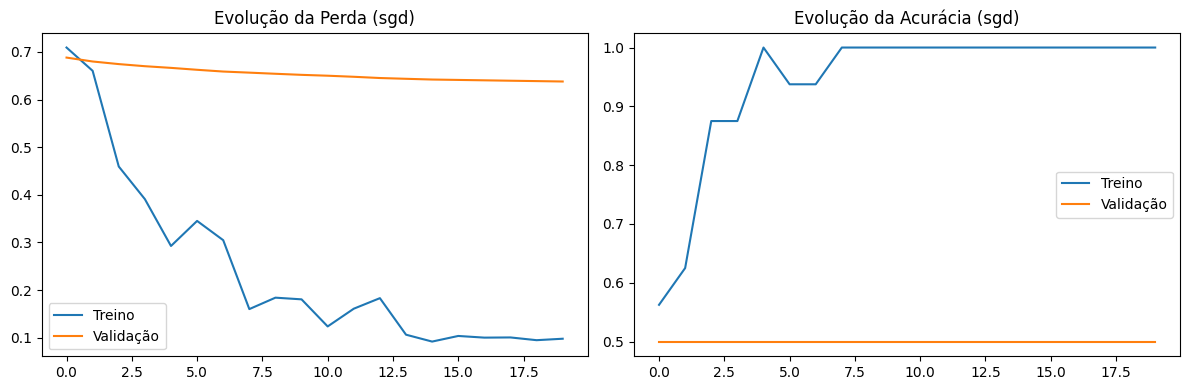

Treinando com otimizador: rmsprop
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.7500 - loss: 0.4416 - val_accuracy: 1.0000 - val_loss: 0.4583 - learning_rate: 1.0000e-04
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.4345 - learning_rate: 1.0000e-04
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 9.7317e-04 - val_accuracy: 1.0000 - val_loss: 0.4297 - learning_rate: 1.0000e-04
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.4264 - learning_rate: 1.0000e-04
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 6.5806e-04 - val_accuracy: 1.0000 - val_loss: 0.4241 - learning_rate: 1.0000e-04
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 6.1142e-04 - val_accuracy: 1.0000 - val_loss: 0.4222 - learning_rate: 1.0000e-04
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 

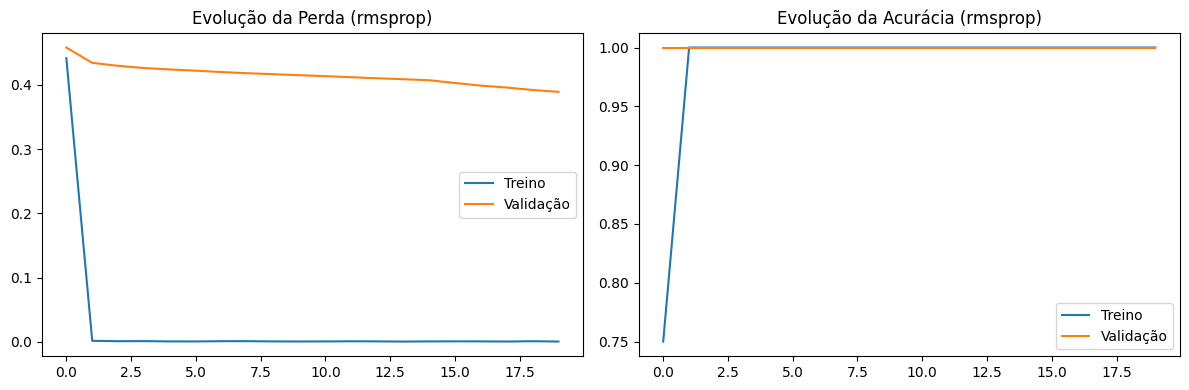

Treinando com otimizador: adam
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.3125 - loss: 0.8857 - val_accuracy: 0.5000 - val_loss: 0.6153 - learning_rate: 1.0000e-04
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0458 - val_accuracy: 0.5000 - val_loss: 0.5833 - learning_rate: 1.0000e-04
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.5000 - val_loss: 0.5769 - learning_rate: 1.0000e-04
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.5000 - val_loss: 0.5797 - learning_rate: 1.0000e-04
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.5000 - val_loss: 0.5868 - learning_rate: 1.0000e-04
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 7.8741e-04 - val_accuracy: 0.5000 - val_loss: 0.5956 - learning_rate: 1.0000e-04
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/ste

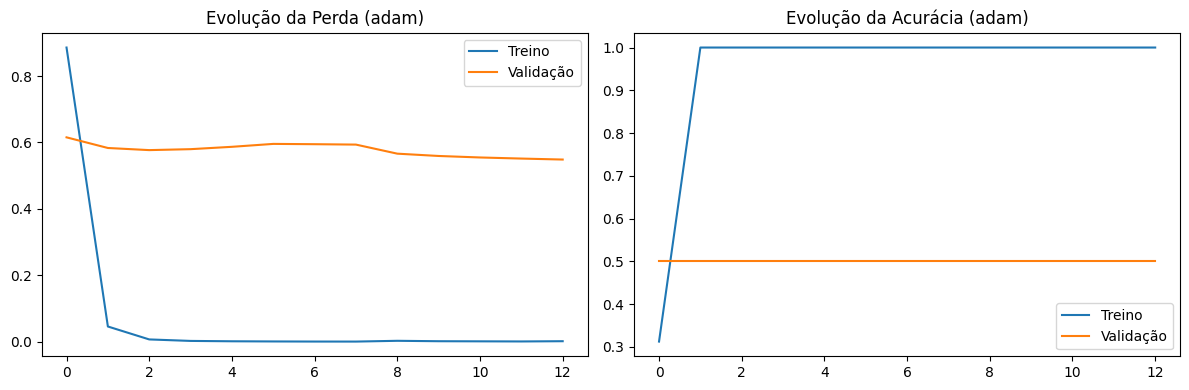

In [ ]:
# Configurações robustas
BASE_LEARNING_RATE = 1e-4
FINE_TUNING_RATE = 1e-5
OPTIMIZERS = {
    'sgd': tf.keras.optimizers.SGD(learning_rate=BASE_LEARNING_RATE),
    'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=BASE_LEARNING_RATE),
    'adam': tf.keras.optimizers.Adam(learning_rate=BASE_LEARNING_RATE)
}

# Garante que a base original permaneça intacta
original_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
original_base_model.trainable = False

for optimizer_name, optimizer in OPTIMIZERS.items():
    print(f"Treinando com otimizador: {optimizer_name}")

    # Cria novo modelo com base clonada
    model = build_model(original_base_model)

    # Compila com configurações robustas
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks aprimorados
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )

    # Treinamento inicial
    history = model.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator,
        callbacks=[early_stopping, reduce_lr]
    )

    # Fine-tuning com segurança
    for layer in model.layers[0].layers[-4:]:  # Acessa a base clonada
        layer.trainable = True

    # Recompila com taxa reduzida
    optimizer_fine = type(optimizer)(learning_rate=FINE_TUNING_RATE)
    model.compile(
        optimizer=optimizer_fine,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Treinamento de fine-tuning
    history_fine = model.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator
    )

    # Combina históricos para visualização completa
    combined_history = {
        'loss': history.history['loss'] + history_fine.history['loss'],
        'val_loss': history.history['val_loss'] + history_fine.history['val_loss'],
        'accuracy': history.history['accuracy'] + history_fine.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'] + history_fine.history['val_accuracy']
    }

    # Visualização aprimorada com matplotlib
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(combined_history['loss'], label='Treino')
    plt.plot(combined_history['val_loss'], label='Validação')
    plt.title(f'Evolução da Perda ({optimizer_name})')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(combined_history['accuracy'], label='Treino')
    plt.plot(combined_history['val_accuracy'], label='Validação')
    plt.title(f'Evolução da Acurácia ({optimizer_name})')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# @title Carregar e pré-processar o conjunto de teste
# Cria diretório de teste separado (se não existir)
os.makedirs('test_data/class_a', exist_ok=True)
os.makedirs('test_data/class_b', exist_ok=True)

print("Diretórios de teste criados com sucesso!")

Diretórios de teste criados com sucesso!


In [ ]:
# Gera dados de teste sintéticos (apenas para demonstração)
for i in range(5):  # 5 amostras por classe
    img = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
    Image.fromarray(img).save(f'test_data/class_a/test_img_{i}.jpg')
    img = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
    Image.fromarray(img).save(f'test_data/class_b/test_img_{i}.jpg')

# Configurações do gerador de dados de teste
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'test_data',  # Diretório separado para teste
    target_size=(224, 224),
    batch_size=1,  # Batch size 1 para cálculo preciso de métricas
    class_mode='binary',
    shuffle=False  # Mantém ordem para análise de erros
)

Found 10 images belonging to 2 classes.


In [ ]:
# Importações necessárias
from sklearn.metrics import classification_report, confusion_matrix

# 2. Avaliação do modelo com métricas avançadas
# Avaliação padrão
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Acurácia de Teste: {test_accuracy * 100:.4f}%')
print(f'Perda de Teste: {test_loss:.4f}')

# Previsões
y_pred = (model.predict(test_generator) > 0.5).astype(int)
y_true = test_generator.classes

# Relatório de classificação com tratamento de divisão por zero
print("\nRelatório de Classificação:")
print(classification_report(
    y_true,
    y_pred,
    target_names=['Classe A', 'Classe B'],
    zero_division=0  # Ignora divisões por zero
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 899ms/step - accuracy: 0.2065 - loss: 1.0968
Acurácia de Teste: 50.0000%
Perda de Teste: 0.8030
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 539ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

    Classe A       0.00      0.00      0.00         5
    Classe B       0.50      1.00      0.67         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10



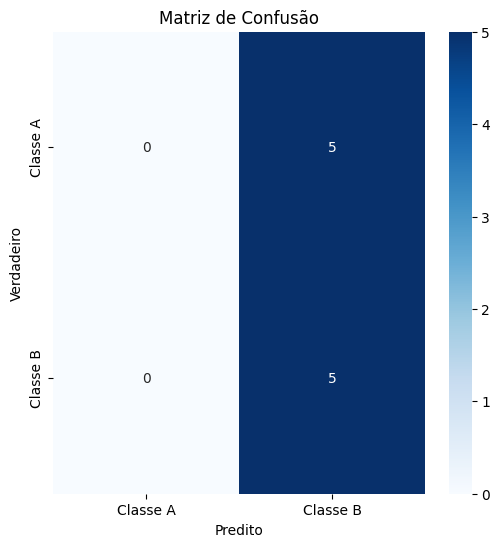

In [ ]:
# Matriz de Confusão
plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Classe A', 'Classe B'],
           yticklabels=['Classe A', 'Classe B'])
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


Exemplos de erro (5 de 10):


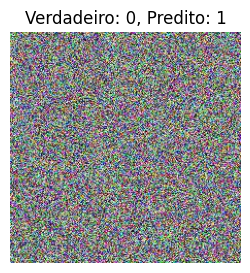

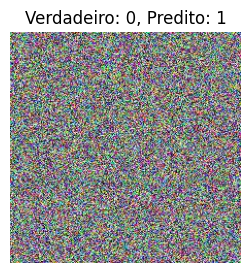

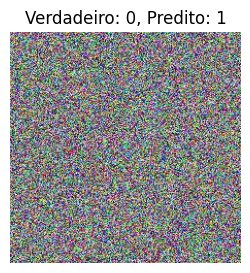

In [ ]:
# 3. Análise de erros
errors = np.where(y_pred.flatten() != y_true)[0]
print(f"\nExemplos de erro ({len(errors)} de {len(y_true)}):")
for idx in errors[:3]:  # Mostra 3 exemplos de erro
    plt.figure(figsize=(3, 3))
    img = Image.open(test_generator.filepaths[idx])
    plt.imshow(img)
    plt.title(f'Verdadeiro: {y_true[idx]}, Predito: {y_pred.flatten()[idx]}')
    plt.axis('off')
    plt.show()